### Author: Brandon Brushwyler

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from IPython.display import display

from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
)

RANDOM_STATE = 321
current_dir = Path.cwd()
sns.set_theme(style="whitegrid")

## Data Loading and Dummy Variable Creation for Categorical Features

In [2]:
candidate_paths = [
    Path("model_data_simple.parquet"),
    Path("../Finalized_Feature_Sets/model_data_simple.parquet"),
    Path("Finalized_Feature_Sets/model_data_simple.parquet"),
    Path("../Random_Forest_Modelling/model_data_simple.parquet"),
]

data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is None:
    raise FileNotFoundError("Could not find model_data_simple.parquet in the expected project locations.")

In [3]:
model_data_simple = pd.read_parquet(
    data_path,
    engine="pyarrow"
)

print(f"Loaded data from: {data_path.resolve()}")

Loaded data from: C:\Users\wolfb\Documents\212b group project\Myocardial-Infarction-ML-Project\Finalized_Feature_Sets\model_data_simple.parquet


In [4]:
model_data_simple["train_dummy"].value_counts(normalize=True)

train_dummy
1    0.749412
0    0.250588
Name: proportion, dtype: float64

In [5]:
model_data_simple.shape

(1700, 31)

In [6]:
model_data_simple.dtypes.value_counts()

Int64       15
float64      9
int64        2
category     1
category     1
category     1
category     1
category     1
Name: count, dtype: int64

In [7]:
feature_cols = model_data_simple.columns.drop(["ZSN", "train_dummy"])

x_train = model_data_simple.loc[model_data_simple["train_dummy"] == 1, feature_cols]
y_train = model_data_simple.loc[model_data_simple["train_dummy"] == 1, "ZSN"].astype(int)

x_test = model_data_simple.loc[model_data_simple["train_dummy"] == 0, feature_cols]
y_test = model_data_simple.loc[model_data_simple["train_dummy"] == 0, "ZSN"].astype(int)

In [8]:

categorical_cols = x_train.select_dtypes(include=["category", "object", "bool"]).columns.tolist()
print("Categorical columns dummy encoded:", categorical_cols)

x_train = pd.get_dummies(
    x_train,
    columns=categorical_cols,
    drop_first=True,
    dtype=float
)
x_test = pd.get_dummies(
    x_test,
    columns=categorical_cols,
    drop_first=True,
    dtype=float
)

x_train, x_test = x_train.align(
    x_test,
    join="left",
    axis=1,
    fill_value=0
)

x_train = x_train.astype(float)
x_test = x_test.astype(float)

print(set(x_train.columns) - set(x_test.columns)) # should be empty set
print(set(x_test.columns) - set(x_train.columns)) # should be empty set

Categorical columns dummy encoded: ['ZSN_A_recode', 'time_bin', 'angina_timing', 'angina_severity', 'htn_duration']
set()
set()


In [9]:
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)
print(x_train.columns.tolist())

(1274, 41) (1274,)
(426, 41) (426,)
['AGE', 'SEX', 'INF_ANAM', 'IBS_POST', 'GB', 'endocr_01', 'S_AD_ORIT', 'D_AD_ORIT', 'O_L_POST', 'MP_TP_POST', 'NA_BLOOD', 'K_BLOOD', 'L_BLOOD', 'ant_im', 'lat_im', 'inf_im', 'post_im', 'ritm_ecg_p_01', 'any_pulmonary_disease', 'any_arrhythmia', 'any_conduction_block', 'ROE_log', 'ALT_BLOOD_log', 'AST_BLOOD_log', 'ZSN_A_recode_missing', 'ZSN_A_recode_moderate_severe', 'ZSN_A_recode_none', 'time_bin_intermediate', 'time_bin_late', 'time_bin_missing', 'angina_timing_missing', 'angina_timing_never', 'angina_timing_recent', 'angina_timing_remote', 'angina_severity_moderate', 'angina_severity_none', 'angina_severity_other', 'htn_duration_medium', 'htn_duration_missing', 'htn_duration_none', 'htn_duration_short']


In [10]:
target_names = ["No Chronic Heart Failure", "Chronic Heart Failure"]

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)


def display_confusion_matrix(y_true, y_pred):
    cnf_matrix = metrics.confusion_matrix(y_true, y_pred)
    cnf_matrix = pd.DataFrame(cnf_matrix)
    cnf_matrix.columns = ["predicted_no_CHF", "predicted_with_CHF"]
    cnf_matrix.index = ["true_no_CHF", "true_with_CHF"]
    display(cnf_matrix)


def choose_threshold_for_recall(model, x, y, desired_recall=0.80):
    y_prob = model.predict_proba(x)[:, 1]
    fpr, tpr, roc_thresholds = roc_curve(y, y_prob)

    valid_idx = np.where(tpr >= desired_recall)[0]
    if len(valid_idx) == 0:
        best_idx = np.argmax(tpr)
    else:
        best_idx = valid_idx[np.argmin(fpr[valid_idx])]

    chosen_threshold = roc_thresholds[best_idx]

    print("Threshold:", chosen_threshold)
    print("Recall:", tpr[best_idx])
    print("FPR:", fpr[best_idx])

    return chosen_threshold


def evaluate_with_threshold(model, x, y, threshold, title):
    y_prob = model.predict_proba(x)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    print("\n------------\n" + title + "\n------------\n")
    print(classification_report(y, y_pred, target_names=target_names))

    print("\n------------\nConfusion matrix\n------------\n")
    display_confusion_matrix(y, y_pred)

    return y_pred


def build_eval_curves(model):
    dict_eval = {}

    for dset in ["train", "test"]:
        if dset == "train":
            x, y = x_train, y_train
        else:
            x, y = x_test, y_test

        y_prob = model.predict_proba(x)[:, 1]

        fpr, tpr, roc_thresholds = roc_curve(y, y_prob)
        roc_auc = roc_auc_score(y, y_prob)

        precision, recall, pr_thresholds = precision_recall_curve(y, y_prob)
        pr_auc = average_precision_score(y, y_prob)

        dict_eval[dset] = {
            "fpr": fpr,
            "tpr": tpr,
            "roc_thresholds": roc_thresholds,
            "roc_auc": roc_auc,
            "prec": precision,
            "recall": recall,
            "pr_thresholds": pr_thresholds,
            "pr_auc": pr_auc,
        }

    return dict_eval


def plot_roc_curves(dict_eval, chosen_threshold, title):
    plt.figure(figsize=(8, 6))

    plt.plot(dict_eval["train"]["fpr"], dict_eval["train"]["tpr"], marker=".", label="Train set")
    plt.plot(dict_eval["test"]["fpr"], dict_eval["test"]["tpr"], marker=".", label="Test set")
    plt.plot([0, 1], [0, 1], linestyle="--", color="grey")

    anno_list = {}

    for dset in ["train", "test"]:
        fpr = dict_eval[dset]["fpr"]
        tpr = dict_eval[dset]["tpr"]
        roc_thresholds = dict_eval[dset]["roc_thresholds"]

        idx = np.argmin(np.abs(roc_thresholds - chosen_threshold))
        fpr_point = fpr[idx]
        tpr_point = tpr[idx]

        plt.plot([fpr_point, fpr_point], [0, tpr_point], linestyle=":", color="grey")
        plt.plot([0, fpr_point], [tpr_point, tpr_point], linestyle=":", color="grey")
        plt.plot([fpr_point], [tpr_point], marker="o", linestyle="None", label=f"{dset} threshold point")

        anno_str = (
            f"{dset}: FPR={fpr_point:.2f}, Recall={tpr_point:.2f}\n"
            f"prob threshold={chosen_threshold:.2f}"
        )

        if dset == "train":
            plt.text(
                fpr_point + 0.02,
                tpr_point + 0.02,
                anno_str,
                fontsize=9,
                bbox=dict(facecolor="white", alpha=0.3, edgecolor="none"),
            )
        else:
            plt.text(
                max(fpr_point - 0.25, 0.02),
                max(tpr_point - 0.12, 0.02),
                anno_str,
                fontsize=9,
                bbox=dict(facecolor="white", alpha=0.3, edgecolor="none"),
            )

        anno_list[dset] = f"AUC({dset}): {dict_eval[dset]['roc_auc']:.2f}"

    auc_str = anno_list["train"] + "\n" + anno_list["test"]
    plt.text(0.60, 0.30, auc_str, bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_pr_curves(dict_eval, chosen_threshold, title):
    plt.figure(figsize=(8, 6))

    plt.plot(dict_eval["train"]["recall"], dict_eval["train"]["prec"], marker=".", label="Train set")
    plt.plot(dict_eval["test"]["recall"], dict_eval["test"]["prec"], marker=".", label="Test set")
    plt.plot([0, 1], [1, 0], linestyle="--", color="grey")

    anno_list = {}

    for dset in ["train", "test"]:
        recall = dict_eval[dset]["recall"]
        precision = dict_eval[dset]["prec"]
        pr_thresholds = dict_eval[dset]["pr_thresholds"]

        if len(pr_thresholds) == 0:
            continue

        idx = np.argmin(np.abs(pr_thresholds - chosen_threshold))
        recall_point = recall[idx]
        precision_point = precision[idx]

        plt.plot([recall_point, recall_point], [0, precision_point], linestyle=":", color="grey")
        plt.plot([0, recall_point], [precision_point, precision_point], linestyle=":", color="grey")
        plt.plot([recall_point], [precision_point], marker="o", linestyle="None", label=f"{dset} threshold point")

        anno_str = (
            f"{dset}: Recall={recall_point:.2f}, Precision={precision_point:.2f}\n"
            f"prob threshold={chosen_threshold:.2f}"
        )

        if dset == "train":
            plt.text(
                max(recall_point - 0.30, 0.02),
                min(precision_point + 0.05, 0.95),
                anno_str,
                fontsize=9,
                bbox=dict(facecolor="white", alpha=0.3, edgecolor="none"),
            )
        else:
            plt.text(
                max(recall_point - 0.35, 0.02),
                max(precision_point - 0.12, 0.02),
                anno_str,
                fontsize=9,
                bbox=dict(facecolor="white", alpha=0.3, edgecolor="none"),
            )

        anno_list[dset] = f"PR AUC({dset}): {dict_eval[dset]['pr_auc']:.2f}"

    auc_str = anno_list["train"] + "\n" + anno_list["test"]
    plt.text(0.05, 0.15, auc_str, fontsize=10, bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

## Logistic Regression

### Exploratory Grid for Hyperparameter Tuning

In [11]:
param_grid_logistic = {
    "log_reg__C": np.logspace(-3, 2, 10),
    "log_reg__penalty": ["l1", "l2"],
    "log_reg__class_weight": [None, "balanced"],
}

In [12]:
logistic_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "log_reg",
            LogisticRegression(
                solver="liblinear",
                max_iter=5000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

logistic_search = RandomizedSearchCV(
    estimator=logistic_pipeline,
    param_distributions=param_grid_logistic,
    n_iter=30,
    scoring="average_precision",   # PR AUC
    cv=cv,
    n_jobs=1,
    random_state=RANDOM_STATE,
    verbose=1,
    return_train_score=True,
)

## Exploratory Cross Validation for Hyperparameter Tuning (using PR AUC as scoring metric)

In [13]:
logistic_search.fit(x_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,Pipeline(step...liblinear'))])
,param_distributions,"{'log_reg__C': array([1.0000...00000000e+02]), 'log_reg__class_weight': [None, 'balanced'], 'log_reg__penalty': ['l1', 'l2']}"
,n_iter,30
,scoring,'average_precision'
,n_jobs,1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,321
,error_score,nan


In [14]:
print("Best PR AUC:", logistic_search.best_score_)
print("Best params:", logistic_search.best_params_)

Best PR AUC: 0.4837846741896309
Best params: {'log_reg__penalty': 'l1', 'log_reg__class_weight': None, 'log_reg__C': np.float64(0.046415888336127795)}


In [15]:
logistic_results = pd.DataFrame(logistic_search.cv_results_)

logistic_results[["mean_train_score", "mean_test_score"]].head()

,mean_train_score,mean_test_score
0,0.494115,0.426091
1,0.570885,0.471651
2,0.571200,0.471676
3,0.571207,0.471652
4,0.563936,0.476674


In [16]:
logistic_results = pd.DataFrame(logistic_search.cv_results_)

cols = [
    "mean_test_score", "std_test_score", "mean_train_score",
    "param_log_reg__C", "param_log_reg__penalty",
    "param_log_reg__class_weight",
]

logistic_results[cols].sort_values("mean_test_score", ascending=False).head(15)

,mean_test_score,std_test_score,mean_train_score,param_log_reg__C,param_log_reg__penalty,param_log_reg__class_weight
17,0.483785,0.034724,0.522782,0.046416,l1,None
14,0.482292,0.046916,0.531477,0.046416,l1,balanced
20,0.480802,0.064855,0.559202,0.166810,l1,balanced
24,0.478094,0.073250,0.562711,0.599484,l1,balanced
28,0.476798,0.073599,0.564216,27.825594,l2,balanced
12,0.476740,0.073620,0.564292,100.000000,l1,balanced
4,0.476674,0.073584,0.563936,27.825594,l1,balanced
29,0.476540,0.073012,0.563518,2.154435,l2,balanced
16,0.476413,0.073071,0.563481,7.742637,l1,balanced
11,0.476298,0.072774,0.563147,0.599484,l2,balanced


__mean_train_score:__ Average PR AUC on the TRAINING folds (in-sample performance)

__mean_test_score:__ Average PR AUC on the VALIDATION folds (out-of-sample cross-validation performance)

## Revised Hyperparameter Grid for Tuning

In [17]:
param_grid_logistic_refined = {
    "log_reg__C": [0.015, 0.02, 0.03, 0.046, 0.06, 0.08, 0.10, 0.15, 0.20, 0.30],
    "log_reg__penalty": ["l1", "l2"],
    "log_reg__class_weight": [None, "balanced"],
}

In [18]:
logistic_search_refined = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=param_grid_logistic_refined,
    scoring="average_precision",
    cv=cv,
    n_jobs=1,
    verbose=1,
    return_train_score=True,
)

In [19]:
logistic_search_refined.fit(x_train, y_train)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


,estimator,Pipeline(step...liblinear'))])
,param_grid,"{'log_reg__C': [0.015, 0.02, ...], 'log_reg__class_weight': [None, 'balanced'], 'log_reg__penalty': ['l1', 'l2']}"
,scoring,'average_precision'
,n_jobs,1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,copy,True


In [20]:
print("Best PR AUC:", logistic_search_refined.best_score_)
print("Best params:", logistic_search_refined.best_params_)

Best PR AUC: 0.4857018167530415
Best params: {'log_reg__C': 0.06, 'log_reg__class_weight': None, 'log_reg__penalty': 'l1'}


In [21]:
logistic_results = pd.DataFrame(logistic_search_refined.cv_results_)

cols = [
    "mean_test_score", "std_test_score", "mean_train_score",
    "param_log_reg__C", "param_log_reg__penalty",
    "param_log_reg__class_weight",
]

logistic_results[cols].sort_values("mean_test_score", ascending=False).head(15)

,mean_test_score,std_test_score,mean_train_score,param_log_reg__C,param_log_reg__penalty,param_log_reg__class_weight
16,0.485702,0.040655,0.536455,0.060,l1,None
18,0.484576,0.053135,0.543626,0.060,l1,balanced
22,0.484009,0.057225,0.551989,0.080,l1,balanced
20,0.483851,0.053308,0.547840,0.080,l1,None
12,0.483621,0.035024,0.522143,0.046,l1,None
14,0.482568,0.046852,0.530854,0.046,l1,balanced
34,0.482507,0.068305,0.559865,0.200,l1,balanced
30,0.481579,0.064994,0.558546,0.150,l1,balanced
38,0.481377,0.071066,0.561505,0.300,l1,balanced
24,0.480965,0.056516,0.554091,0.100,l1,None


## Additional Visualization of Hyperparameter Tuning Results

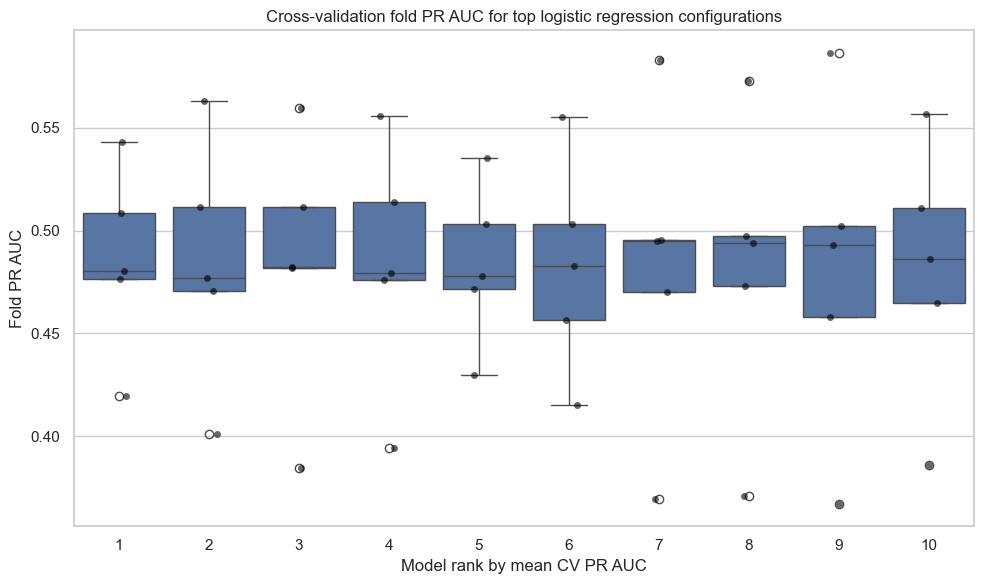

In [22]:
logistic_results = pd.DataFrame(logistic_search_refined.cv_results_)

top = logistic_results.sort_values("mean_test_score", ascending=False).head(10).copy()
top["model_rank"] = range(1, len(top) + 1)

fold_cols = [c for c in logistic_results.columns if c.startswith("split") and c.endswith("_test_score")]

top_long = top.melt(
    id_vars=["model_rank", "mean_test_score"],
    value_vars=fold_cols,
    var_name="fold",
    value_name="pr_auc",
)

plt.figure(figsize=(10, 6))
sns.boxplot(data=top_long, x="model_rank", y="pr_auc")
sns.stripplot(data=top_long, x="model_rank", y="pr_auc", color="black", alpha=0.6)

plt.xlabel("Model rank by mean CV PR AUC")
plt.ylabel("Fold PR AUC")
plt.title("Cross-validation fold PR AUC for top logistic regression configurations")
plt.tight_layout()
plt.show()

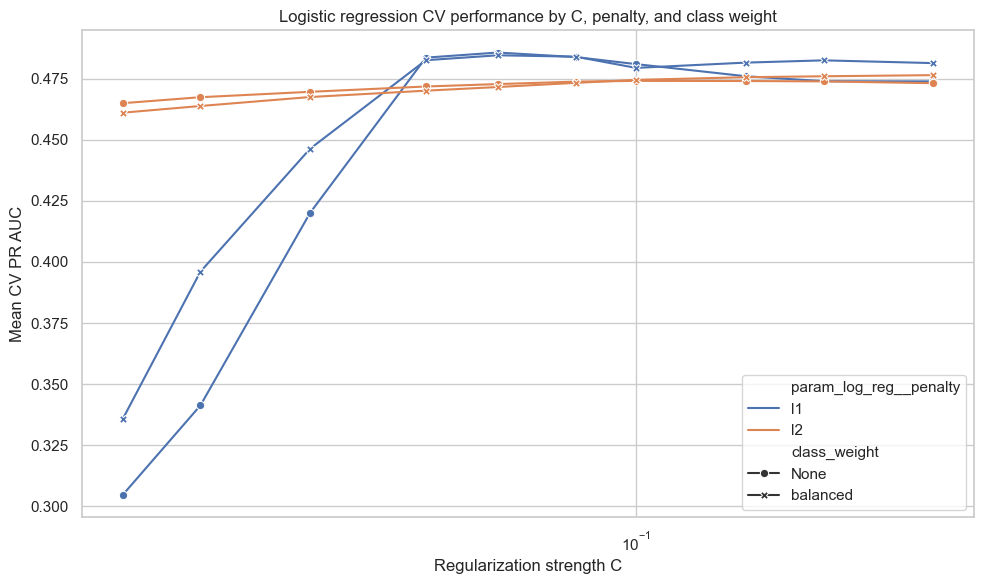

In [23]:
logistic_results["class_weight"] = logistic_results["param_log_reg__class_weight"].astype(str)

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=logistic_results,
    x="param_log_reg__C",
    y="mean_test_score",
    hue="param_log_reg__penalty",
    style="class_weight",
    markers=True,
    dashes=False,
)

plt.xscale("log")
plt.ylabel("Mean CV PR AUC")
plt.xlabel("Regularization strength C")
plt.title("Logistic regression CV performance by C, penalty, and class weight")
plt.tight_layout()
plt.show()

## Metrics on The Training Data Itself for the Best Logistic Regression Model

In [24]:
best_logistic = logistic_search_refined.best_estimator_
y_train_pred_logistic = best_logistic.predict(x_train)

In [25]:
print(classification_report(y_train, y_train_pred_logistic, target_names=target_names))

                          precision    recall  f1-score   support

No Chronic Heart Failure       0.82      0.99      0.89       988
   Chronic Heart Failure       0.86      0.23      0.36       286

                accuracy                           0.82      1274
               macro avg       0.84      0.61      0.63      1274
            weighted avg       0.82      0.82      0.77      1274



In [26]:
display_confusion_matrix(y_train, y_train_pred_logistic)

,predicted_no_CHF,predicted_with_CHF
true_no_CHF,977,11
true_with_CHF,221,65


In [27]:
coef = best_logistic.named_steps["log_reg"].coef_[0]
coef_table = pd.DataFrame(
    {
        "feature": x_train.columns,
        "coefficient": coef,
        "absolute_magnitude": np.abs(coef),
    }
).sort_values("absolute_magnitude", ascending=False)

coef_table.head(15)

,feature,coefficient,absolute_magnitude
26,ZSN_A_recode_none,-0.768585,0.768585
24,ZSN_A_recode_missing,-0.440778,0.440778
25,ZSN_A_recode_moderate_severe,-0.354291,0.354291
0,AGE,0.163074,0.163074
18,any_pulmonary_disease,0.148704,0.148704
5,endocr_01,0.135110,0.135110
6,S_AD_ORIT,0.120638,0.120638
17,ritm_ecg_p_01,-0.080518,0.080518
9,MP_TP_POST,0.036715,0.036715
22,ALT_BLOOD_log,0.035336,0.035336


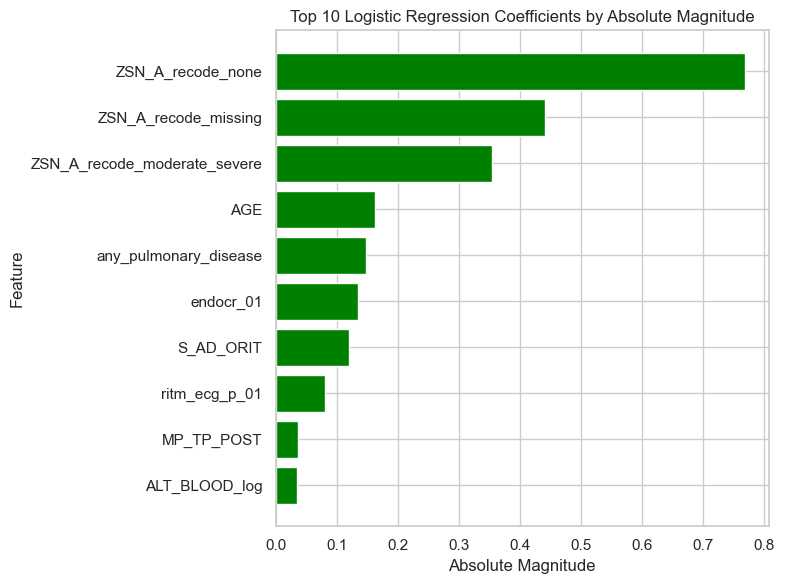

In [65]:
top10_coef = (
    coef_table.assign(absolute_magnitude=coef_table["coefficient"].abs())
    .nlargest(10, "absolute_magnitude")
    .sort_values("absolute_magnitude")
)

plt.figure(figsize=(8, 6))
plt.barh(top10_coef["feature"], top10_coef["absolute_magnitude"], color="green")
plt.xlabel("Absolute Magnitude")
plt.ylabel("Feature")
plt.title("Top 10 Logistic Regression Coefficients by Absolute Magnitude")
plt.tight_layout()
plt.show()

## Evaluating Logistic Regression Model Performance on Test Set

In [29]:
# Predict Y values of test data using the default 0.5 threshold
y_test_pred_logistic = best_logistic.predict(x_test)

print("\n------------\n" +
      "Classification report on test data" +
      "\n------------\n")
print(classification_report(y_test, y_test_pred_logistic, target_names=target_names))

print("\n------------\n" +
      "Confusion matrix on test data" +
      "\n------------\n")
display_confusion_matrix(y_test, y_test_pred_logistic)


------------
Classification report on test data
------------

                          precision    recall  f1-score   support

No Chronic Heart Failure       0.79      0.99      0.88       318
   Chronic Heart Failure       0.89      0.23      0.37       108

                accuracy                           0.80       426
               macro avg       0.84      0.61      0.62       426
            weighted avg       0.82      0.80      0.75       426


------------
Confusion matrix on test data
------------



,predicted_no_CHF,predicted_with_CHF
true_no_CHF,315,3
true_with_CHF,83,25


Using the default probability threshold of 0.5 can be inappropriate in imbalanced clinical prediction tasks because it may miss too many CHF cases. The next cells choose a threshold on the training set only, then apply it once to the held-out test set.

In [30]:
# threshold selection using ROC curve analysis, on the training set to avoid data leakage and overfitting to the test set
logistic_threshold = choose_threshold_for_recall(
    best_logistic,
    x_train,
    y_train,
    desired_recall=0.80,
)

Threshold: 0.1869981940592962
Recall: 0.8006993006993007
FPR: 0.507085020242915


In [31]:
y_test_pred_logistic_adjusted = evaluate_with_threshold(
    best_logistic,
    x_test,
    y_test,
    logistic_threshold,
    "Classification report on test data with adjusted threshold",
)


------------
Classification report on test data with adjusted threshold
------------

                          precision    recall  f1-score   support

No Chronic Heart Failure       0.84      0.50      0.63       318
   Chronic Heart Failure       0.33      0.72      0.45       108

                accuracy                           0.56       426
               macro avg       0.59      0.61      0.54       426
            weighted avg       0.71      0.56      0.59       426


------------
Confusion matrix
------------



,predicted_no_CHF,predicted_with_CHF
true_no_CHF,160,158
true_with_CHF,30,78


## ROC Curve (Receiver Operating Curve), AUC (Area Under the Curve)

In [32]:
logistic_eval = build_eval_curves(best_logistic)

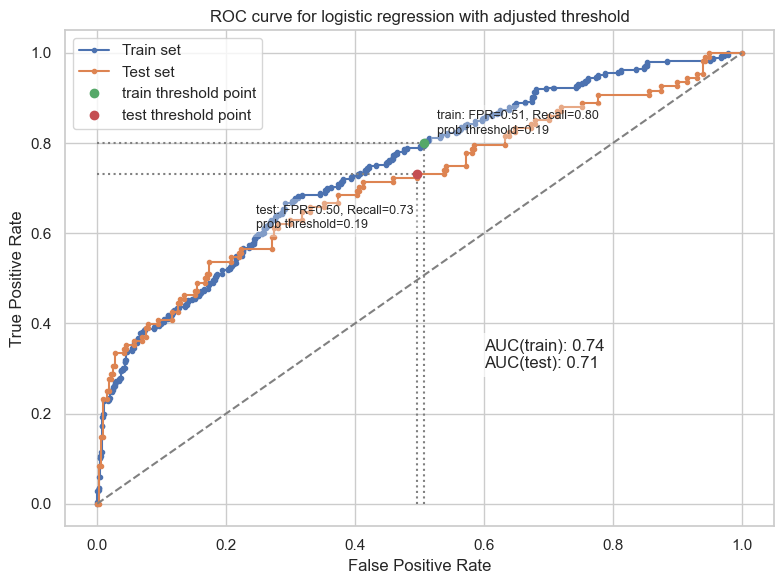

In [33]:
plot_roc_curves(
    logistic_eval,
    logistic_threshold,
    "ROC curve for logistic regression with adjusted threshold",
)

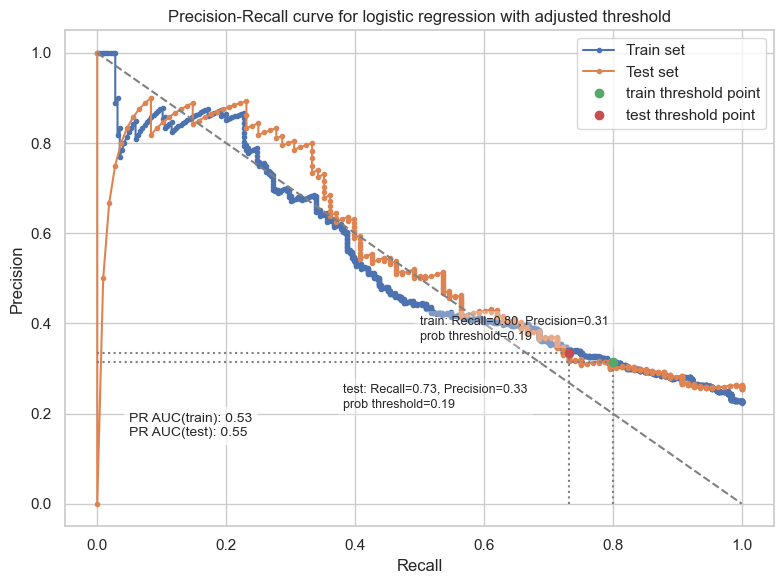

In [34]:
plot_pr_curves(
    logistic_eval,
    logistic_threshold,
    "Precision-Recall curve for logistic regression with adjusted threshold",
)

https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

## Classification Tree

### Exploratory Grid for Hyperparameter Tuning

In [35]:
# Exploratory Grid for Hyperparameter Tuning

param_grid_tree = {
    "max_depth": [2, 3, 4, 5, 6, 8, 10, None],
    "min_samples_leaf": [1, 5, 10, 20, 40],
    "min_samples_split": [2, 10, 20, 40],
    "criterion": ["gini", "entropy"],
    "class_weight": [None, "balanced"],
}

In [36]:
tree = DecisionTreeClassifier(
    random_state=RANDOM_STATE,
)

tree_search = RandomizedSearchCV(
    estimator=tree,
    param_distributions=param_grid_tree,
    n_iter=80,
    scoring="average_precision",   # PR AUC
    cv=cv,
    n_jobs=1,
    random_state=RANDOM_STATE,
    verbose=1,
    return_train_score=True,
)

## Exploratory Cross Validation for Hyperparameter Tuning (using PR AUC as scoring metric)

In [37]:
tree_search.fit(x_train, y_train)

Fitting 5 folds for each of 80 candidates, totalling 400 fits


,estimator,DecisionTreeC...dom_state=321)
,param_distributions,"{'class_weight': [None, 'balanced'], 'criterion': ['gini', 'entropy'], 'max_depth': [2, 3, ...], 'min_samples_leaf': [1, 5, ...], ...}"
,n_iter,80
,scoring,'average_precision'
,n_jobs,1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,321
,error_score,nan


In [38]:
print("Best PR AUC:", tree_search.best_score_)
print("Best params:", tree_search.best_params_)

Best PR AUC: 0.45272342619674816
Best params: {'min_samples_split': 20, 'min_samples_leaf': 1, 'max_depth': 6, 'criterion': 'gini', 'class_weight': 'balanced'}


In [39]:
tree_results = pd.DataFrame(tree_search.cv_results_)

tree_results[["mean_train_score", "mean_test_score"]].head()

,mean_train_score,mean_test_score
0,0.669472,0.407941
1,0.693270,0.379531
2,0.627240,0.442088
3,0.624678,0.438173
4,0.475161,0.367527


In [40]:
tree_results = pd.DataFrame(tree_search.cv_results_)

cols = [
    "mean_test_score", "std_test_score", "mean_train_score",
    "param_max_depth", "param_min_samples_leaf",
    "param_min_samples_split", "param_criterion",
    "param_class_weight",
]

tree_results[cols].sort_values("mean_test_score", ascending=False).head(15)

,mean_test_score,std_test_score,mean_train_score,param_max_depth,param_min_samples_leaf,param_min_samples_split,param_criterion,param_class_weight
21,0.452723,0.031464,0.630411,6,1,20,gini,balanced
62,0.446343,0.047405,0.612528,8,20,20,gini,None
69,0.443331,0.046496,0.611129,8,20,2,gini,balanced
31,0.443152,0.047809,0.627532,10,20,2,gini,balanced
2,0.442088,0.047852,0.627240,None,20,10,gini,balanced
25,0.441944,0.057067,0.630946,8,5,40,gini,None
70,0.439300,0.041813,0.622900,10,20,40,entropy,None
3,0.438173,0.040709,0.624678,None,20,20,entropy,None
23,0.437812,0.049220,0.586722,6,10,40,gini,None
50,0.435465,0.059396,0.653086,10,5,40,gini,None


__mean_train_score:__ Average PR AUC on the TRAINING folds (in-sample performance)

__mean_test_score:__ Average PR AUC on the VALIDATION folds (out-of-sample cross-validation performance)

## Revised Hyperparameter Grid for Tuning

In [41]:
param_grid_tree_refined = {
    "max_depth": [3, 4, 5, 6, 7, 8, 9, 10],
    "min_samples_leaf": [1, 3, 5, 7, 10, 15, 20, 25, 30, 40],
    "min_samples_split": [2, 5, 10, 20],
    "criterion": ["gini", "entropy"],
    "class_weight": [None, "balanced"],
}

In [42]:
tree_search_refined = GridSearchCV(
    estimator=tree,
    param_grid=param_grid_tree_refined,
    scoring="average_precision",
    cv=cv,
    n_jobs=1,
    verbose=1,
    return_train_score=True,
)

In [43]:
tree_search_refined.fit(x_train, y_train)

Fitting 5 folds for each of 1280 candidates, totalling 6400 fits


,estimator,DecisionTreeC...dom_state=321)
,param_grid,"{'class_weight': [None, 'balanced'], 'criterion': ['gini', 'entropy'], 'max_depth': [3, 4, ...], 'min_samples_leaf': [1, 3, ...], ...}"
,scoring,'average_precision'
,n_jobs,1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,criterion,'gini'


In [44]:
print("Best PR AUC:", tree_search_refined.best_score_)
print("Best params:", tree_search_refined.best_params_)

Best PR AUC: 0.45501263543698356
Best params: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10}


In [45]:
tree_results = pd.DataFrame(tree_search_refined.cv_results_)

cols = [
    "mean_test_score", "std_test_score", "mean_train_score",
    "param_max_depth", "param_min_samples_leaf",
    "param_min_samples_split", "param_criterion",
    "param_class_weight",
]

tree_results[cols].sort_values("mean_test_score", ascending=False).head(15)

,mean_test_score,std_test_score,mean_train_score,param_max_depth,param_min_samples_leaf,param_min_samples_split,param_criterion,param_class_weight
722,0.455013,0.044815,0.585175,5,1,10,gini,balanced
183,0.454968,0.056680,0.621814,7,15,20,gini,None
180,0.454968,0.056680,0.621814,7,15,2,gini,None
181,0.454968,0.056680,0.621814,7,15,5,gini,None
182,0.454968,0.056680,0.621814,7,15,10,gini,None
763,0.452723,0.031464,0.630411,6,1,20,gini,balanced
187,0.451991,0.049970,0.601235,7,20,20,gini,None
186,0.451991,0.049970,0.601235,7,20,10,gini,None
185,0.451991,0.049970,0.601235,7,20,5,gini,None
184,0.451991,0.049970,0.601235,7,20,2,gini,None


## Additional Visualization of Hyperparameter Tuning Results

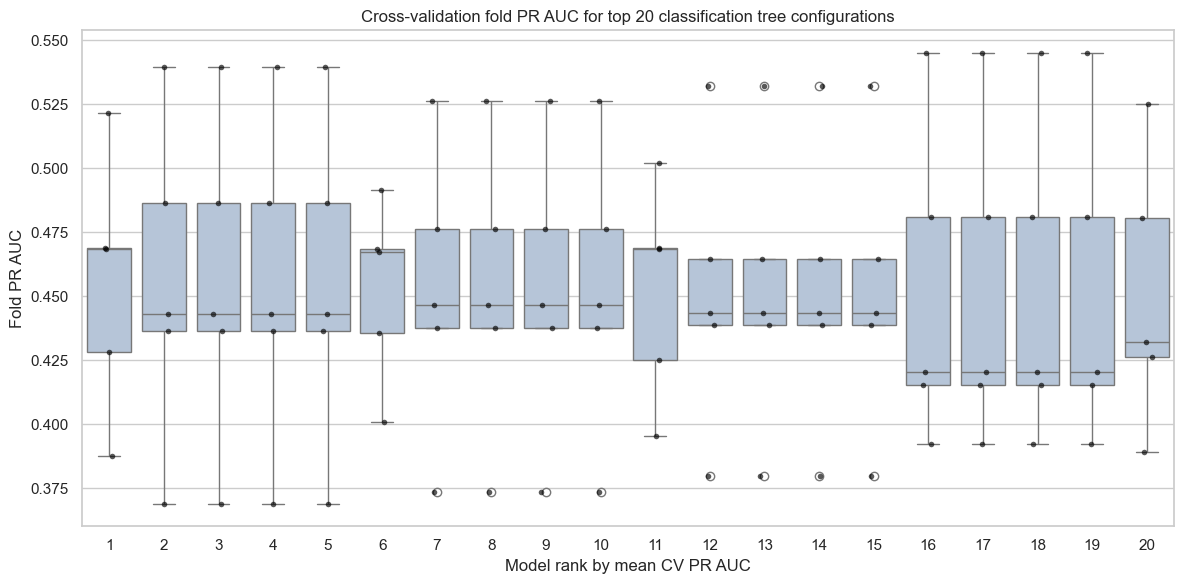

In [46]:
tree_results = pd.DataFrame(tree_search_refined.cv_results_)

# get top 20 configs by mean CV PR AUC so the fold-level plot shows more tuned trees
top = tree_results.sort_values("mean_test_score", ascending=False).head(20).copy()
top["model_rank"] = range(1, len(top) + 1)

fold_cols = [c for c in tree_results.columns if c.startswith("split") and c.endswith("_test_score")]

top_long = top.melt(
    id_vars=["model_rank", "mean_test_score"],
    value_vars=fold_cols,
    var_name="fold",
    value_name="pr_auc",
)

plt.figure(figsize=(12, 6))
sns.boxplot(data=top_long, x="model_rank", y="pr_auc", color="lightsteelblue")
sns.stripplot(data=top_long, x="model_rank", y="pr_auc", color="black", alpha=0.65, size=4)

plt.xlabel("Model rank by mean CV PR AUC")
plt.ylabel("Fold PR AUC")
plt.title("Cross-validation fold PR AUC for top 20 classification tree configurations")
plt.tight_layout()
plt.show() # points are jittered for visibility

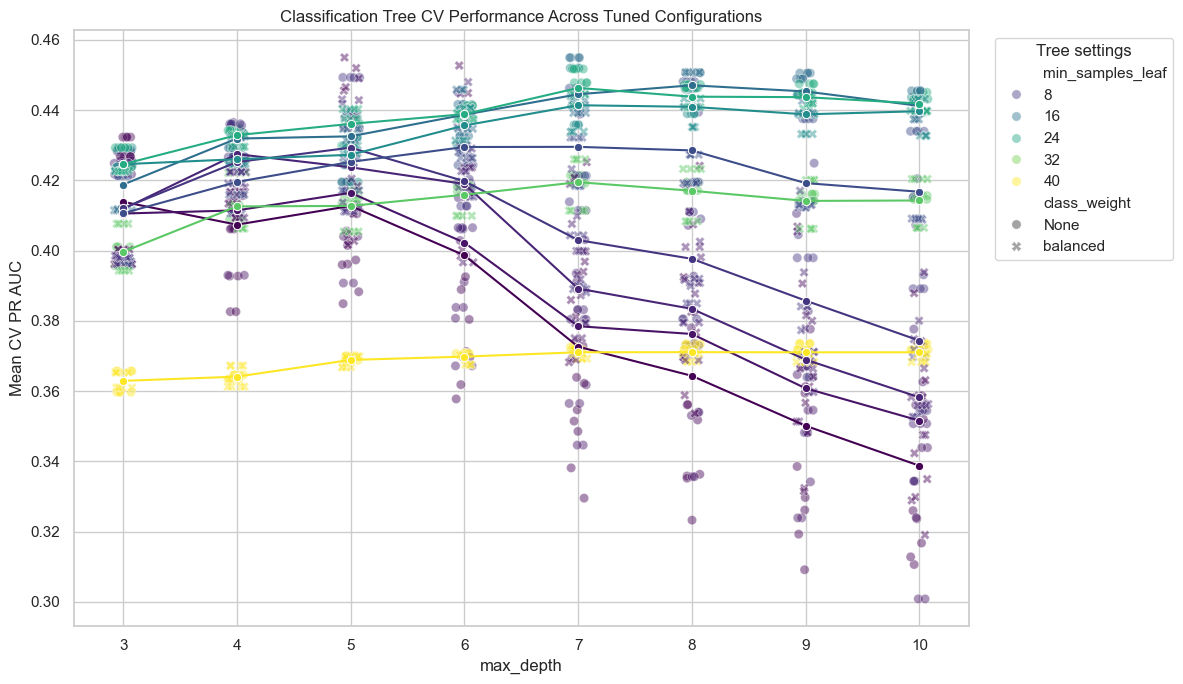

In [47]:
tree_plot_data = tree_results.copy()
tree_plot_data["max_depth"] = tree_plot_data["param_max_depth"].astype(int)
tree_plot_data["min_samples_leaf"] = tree_plot_data["param_min_samples_leaf"].astype(int)
tree_plot_data["class_weight"] = tree_plot_data["param_class_weight"].astype(str)

rng = np.random.default_rng(RANDOM_STATE)
tree_plot_data["max_depth_jittered"] = tree_plot_data["max_depth"] + rng.uniform(
    -0.08,
    0.08,
    size=len(tree_plot_data),
)

plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=tree_plot_data,
    x="max_depth_jittered",
    y="mean_test_score",
    hue="min_samples_leaf",
    style="class_weight",
    alpha=0.45,
    s=45,
    palette="viridis",
)
sns.lineplot(
    data=tree_plot_data,
    x="max_depth",
    y="mean_test_score",
    hue="min_samples_leaf",
    estimator="mean",
    errorbar=None,
    marker="o",
    linewidth=1.5,
    legend=False,
    palette="viridis",
)

plt.xticks(sorted(tree_plot_data["max_depth"].unique()))
plt.ylabel("Mean CV PR AUC")
plt.xlabel("max_depth")
plt.title("Classification Tree CV Performance Across Tuned Configurations")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Tree settings")
plt.tight_layout()
plt.show()

## Metrics on The Training Data Itself for the Best Classification Tree Model

In [48]:
best_tree = tree_search_refined.best_estimator_
y_train_pred_tree = best_tree.predict(x_train)

In [49]:
print(classification_report(y_train, y_train_pred_tree, target_names=target_names))

                          precision    recall  f1-score   support

No Chronic Heart Failure       0.87      0.85      0.86       988
   Chronic Heart Failure       0.53      0.56      0.54       286

                accuracy                           0.79      1274
               macro avg       0.70      0.71      0.70      1274
            weighted avg       0.79      0.79      0.79      1274



In [50]:
display_confusion_matrix(y_train, y_train_pred_tree)

,predicted_no_CHF,predicted_with_CHF
true_no_CHF,844,144
true_with_CHF,126,160


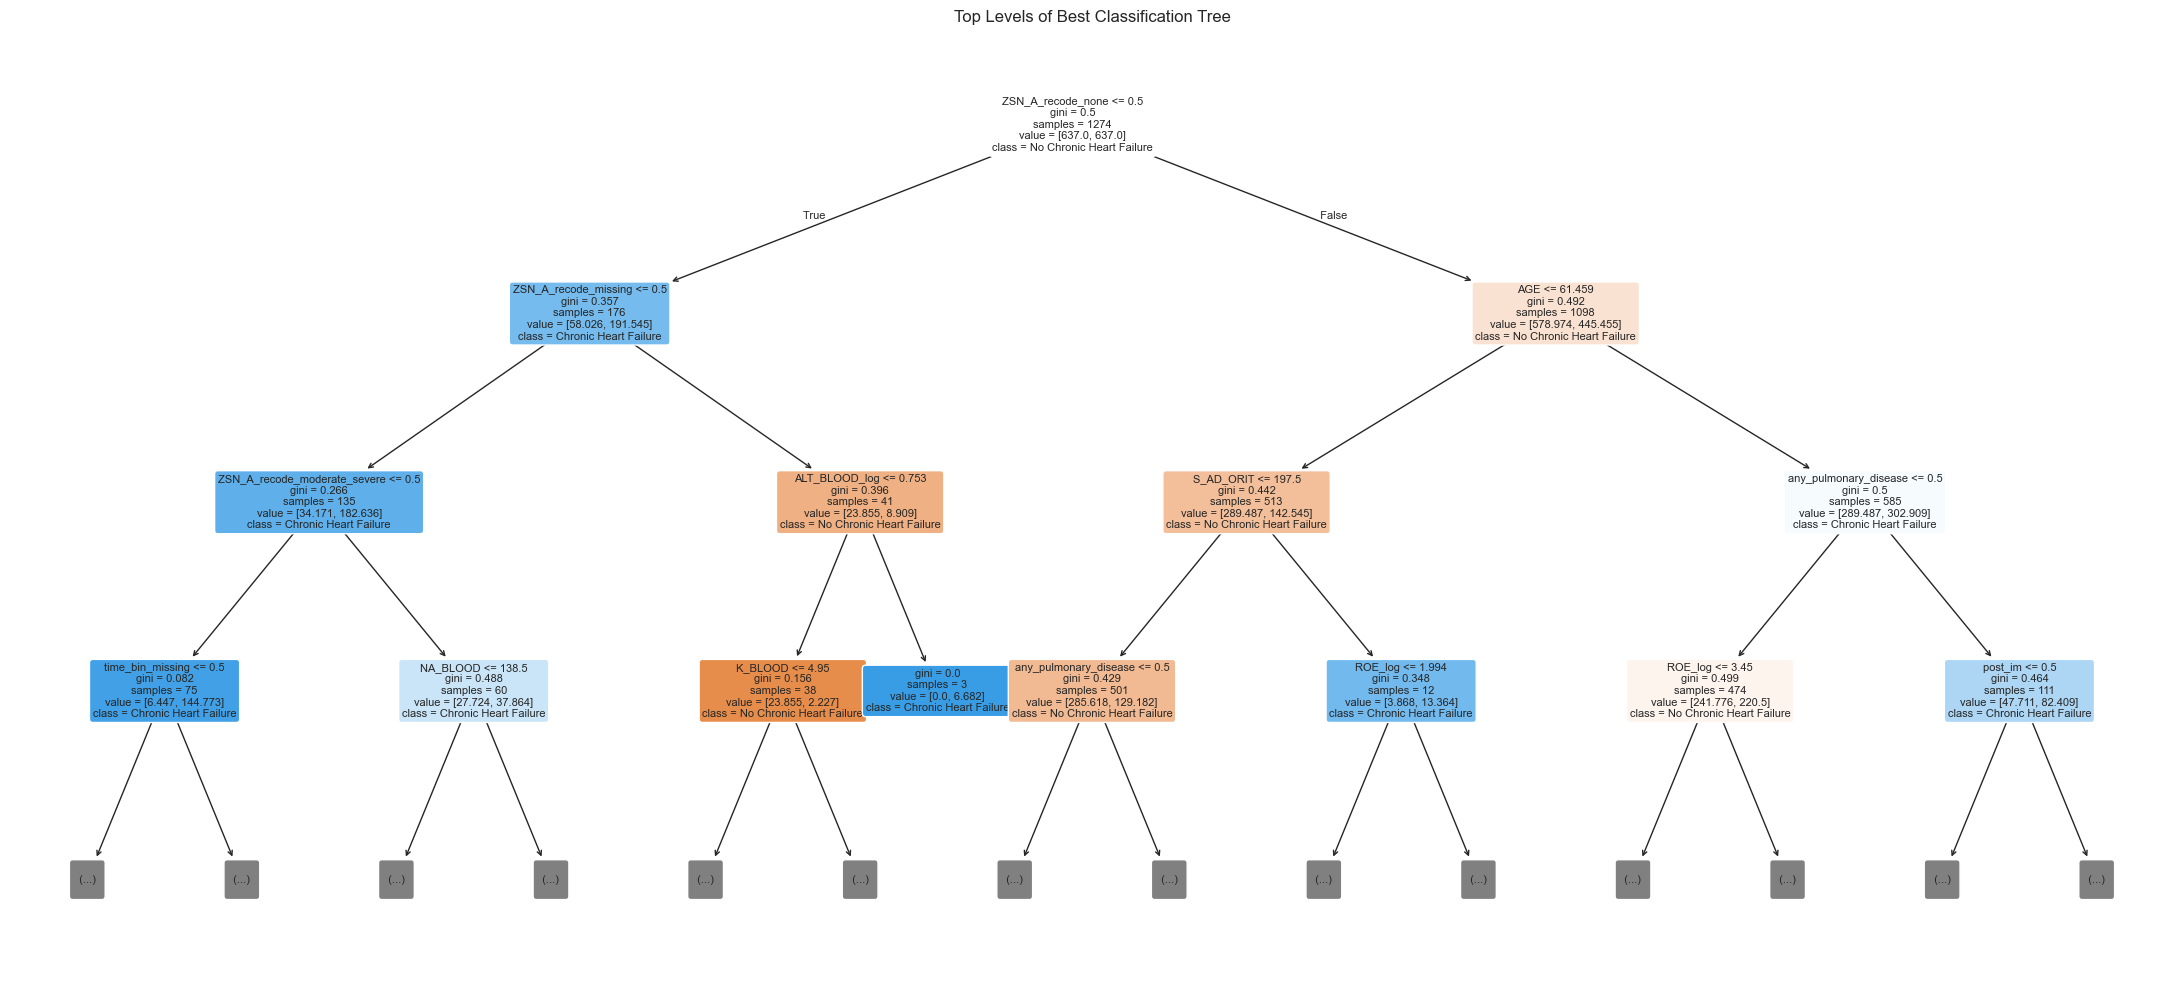

In [51]:
plt.figure(figsize=(22, 10))
plot_tree(
    best_tree,
    feature_names=x_train.columns,
    class_names=target_names,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8,
)
plt.title("Top Levels of Best Classification Tree")
plt.tight_layout()
plt.show()

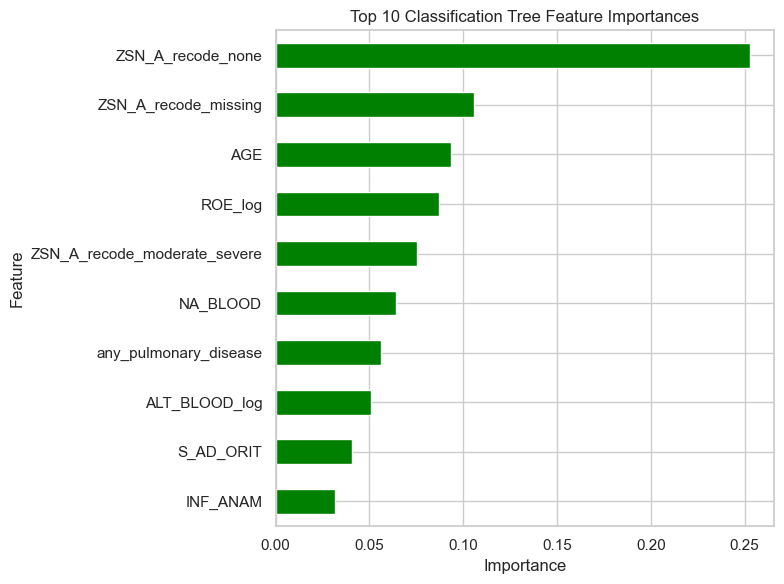

In [52]:
feature_imp_tree = pd.Series(best_tree.feature_importances_, index=x_train.columns)

# subset to top 10 features for better visualization
top10_tree = feature_imp_tree.sort_values(ascending=False).head(10)

top10_tree.sort_values().plot.barh(color="green", figsize=(8, 6))
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Classification Tree Feature Importances")
plt.tight_layout()
plt.show()

## Evaluating Classification Tree Model Performance on Test Set

In [53]:
# Predict Y values of test data using the default 0.5 threshold
y_test_pred_tree = best_tree.predict(x_test)

print("\n------------\n" +
      "Classification report on test data" +
      "\n------------\n")
print(classification_report(y_test, y_test_pred_tree, target_names=target_names))

print("\n------------\n" +
      "Confusion matrix on test data" +
      "\n------------\n")
display_confusion_matrix(y_test, y_test_pred_tree)


------------
Classification report on test data
------------

                          precision    recall  f1-score   support

No Chronic Heart Failure       0.81      0.84      0.82       318
   Chronic Heart Failure       0.46      0.42      0.44       108

                accuracy                           0.73       426
               macro avg       0.64      0.63      0.63       426
            weighted avg       0.72      0.73      0.73       426


------------
Confusion matrix on test data
------------



,predicted_no_CHF,predicted_with_CHF
true_no_CHF,266,52
true_with_CHF,63,45


As with logistic regression, the classification tree threshold is selected using training-set ROC behavior and then evaluated on the held-out test set.

In [54]:
# threshold selection using ROC curve analysis, on the training set to avoid data leakage and overfitting to the test set
tree_threshold = choose_threshold_for_recall(
    best_tree,
    x_train,
    y_train,
    desired_recall=0.80,
)

Threshold: 0.4722353311310373
Recall: 0.8356643356643356
FPR: 0.45445344129554655


In [55]:
y_test_pred_tree_adjusted = evaluate_with_threshold(
    best_tree,
    x_test,
    y_test,
    tree_threshold,
    "Classification report on test data with adjusted threshold",
)


------------
Classification report on test data with adjusted threshold
------------

                          precision    recall  f1-score   support

No Chronic Heart Failure       0.85      0.54      0.66       318
   Chronic Heart Failure       0.35      0.73      0.47       108

                accuracy                           0.59       426
               macro avg       0.60      0.63      0.57       426
            weighted avg       0.73      0.59      0.61       426


------------
Confusion matrix
------------



,predicted_no_CHF,predicted_with_CHF
true_no_CHF,171,147
true_with_CHF,29,79


## ROC Curve (Receiver Operating Curve), AUC (Area Under the Curve)

In [56]:
tree_eval = build_eval_curves(best_tree)

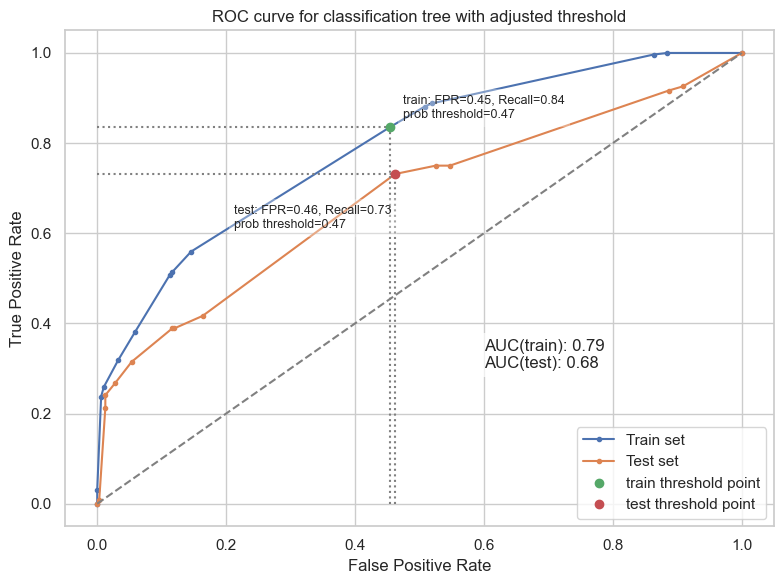

In [57]:
plot_roc_curves(
    tree_eval,
    tree_threshold,
    "ROC curve for classification tree with adjusted threshold",
)

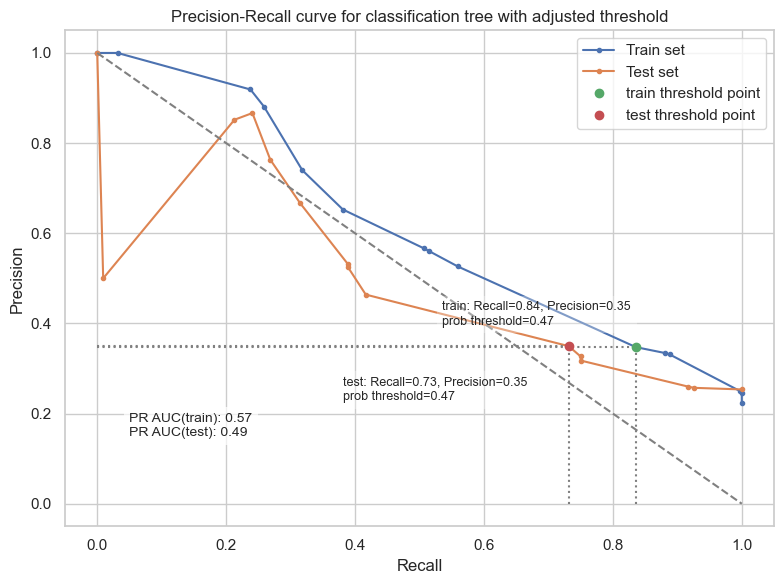

In [58]:
plot_pr_curves(
    tree_eval,
    tree_threshold,
    "Precision-Recall curve for classification tree with adjusted threshold",
)

## Model Comparison Summary

In [59]:
comparison = pd.DataFrame(
    {
        "model": ["Logistic Regression", "Classification Tree"],
        "best_cv_pr_auc": [
            logistic_search_refined.best_score_,
            tree_search_refined.best_score_,
        ],
        "test_pr_auc": [
            average_precision_score(y_test, best_logistic.predict_proba(x_test)[:, 1]),
            average_precision_score(y_test, best_tree.predict_proba(x_test)[:, 1]),
        ],
        "test_roc_auc": [
            roc_auc_score(y_test, best_logistic.predict_proba(x_test)[:, 1]),
            roc_auc_score(y_test, best_tree.predict_proba(x_test)[:, 1]),
        ],
        "chosen_threshold": [
            logistic_threshold,
            tree_threshold,
        ],
    }
)

comparison

,model,best_cv_pr_auc,test_pr_auc,test_roc_auc,chosen_threshold
0,Logistic Regression,0.485702,0.551054,0.709964,0.186998
1,Classification Tree,0.455013,0.487121,0.679202,0.472235
